<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Exercise 01: Simple Linear Regression

We revisit Galton's father-son height data to practise two things: small-sample $t$-tests as a warm-up, and the mechanics of the simple linear regression model from Lecture 1,

$$Y_i = \beta_0 + \beta_1 x_i + e_i, \qquad i = 1, \dots, n, \qquad (\ast)$$

where $x_i$ is the **explanatory variable** (also independent variable, predictor, regressor, covariate; Czech: vysvětlující proměnná), $Y_i$ is the **response** (dependent variable, outcome; vysvětlovaná proměnná), $\beta_0$ is the **intercept** (absolutní člen) and $\beta_1$ the **slope** (směrnice), and $e_1, \dots, e_n$ are independent **random errors** (noise, disturbances; náhodné chyby) with $\mathrm{E}\, e_i = 0$ and $\mathrm{Var}(e_i) = \sigma^2$. The values $x_i$ are treated as fixed, the randomness enters through $e_i$.

We fit the line by least squares in several equivalent ways, compute the residuals and the estimates of $\sigma^2$, and preview the standard errors of the coefficients that Lecture 2 will derive. Python is our tool, but the lectures show R output, so R equivalents are mentioned in brackets where useful.

## Learning goals
- Refresh exploratory summaries for a bivariate dataset.
- Recap one-sample and paired $t$-tests using both manual formulas and `scipy` helpers.
- Compute the least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$ from the lecture formula and confirm that several computational routes agree.
- Distinguish the maximum likelihood estimate $\widehat{\sigma}^2$ from the unbiased estimate $s_n^2$ of the error variance, and know what the standard error of the regression $s_n$ is called in R and in `statsmodels`.
- Preview Lecture 2: standard errors of $\widehat{\beta}_0, \widehat{\beta}_1$, the `statsmodels` summary table and the lecture's speed-of-sound example.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.3f}'.format)

## 2. Load and inspect the dataset
The file `fsdata.csv` contains Galton's measurements (in inches) for 1,078 father-son pairs. The first column of the file is just the R row index, so we use it as the DataFrame index.

In [2]:
url_fsdata = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/fsdata.csv'
fsdata = pd.read_csv(url_fsdata, index_col=0)
print(f'Rows: {fsdata.shape[0]}, columns: {fsdata.shape[1]}')
fsdata.head()

Rows: 1078, columns: 2


,father,son
1,65.049,59.778
2,63.251,63.214
3,64.955,63.342
4,65.752,62.792
5,61.137,64.281


### Structural overview

In [3]:
fsdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1078 entries, 1 to 1078
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   father  1078 non-null   float64
 1   son     1078 non-null   float64
dtypes: float64(2)
memory usage: 25.3 KB


In [4]:
fsdata.describe().T

,count,mean,std,min,25%,50%,75%,max
father,1078.000,67.687,2.745,59.008,65.788,67.767,69.603,75.434
son,1078.000,68.684,2.815,58.507,66.931,68.616,70.466,78.365


## 3. Exploring the distributions
Visual checks help confirm that the marginal distributions look roughly symmetric and that father and son heights are positively related.

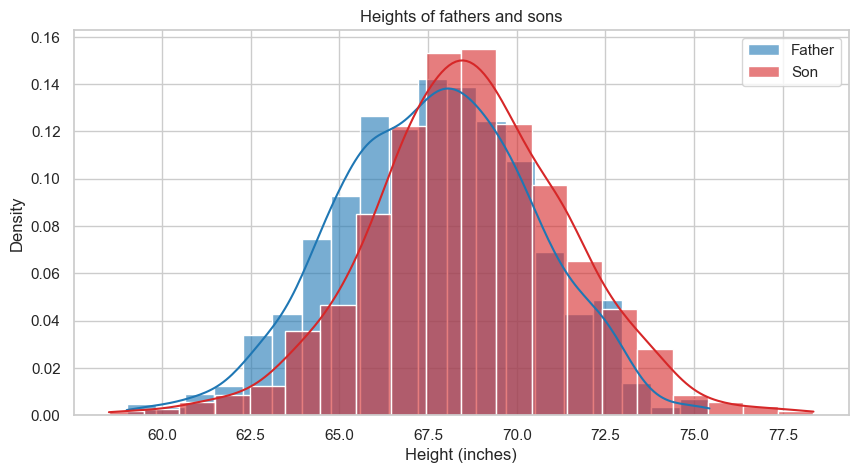

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(fsdata, x='father', bins=20, color='#1f77b4', kde=True, stat='density', alpha=0.6, label='Father')
sns.histplot(fsdata, x='son', bins=20, color='#d62728', kde=True, stat='density', alpha=0.6, label='Son')

plt.title('Heights of fathers and sons')
plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.legend()
plt.show()

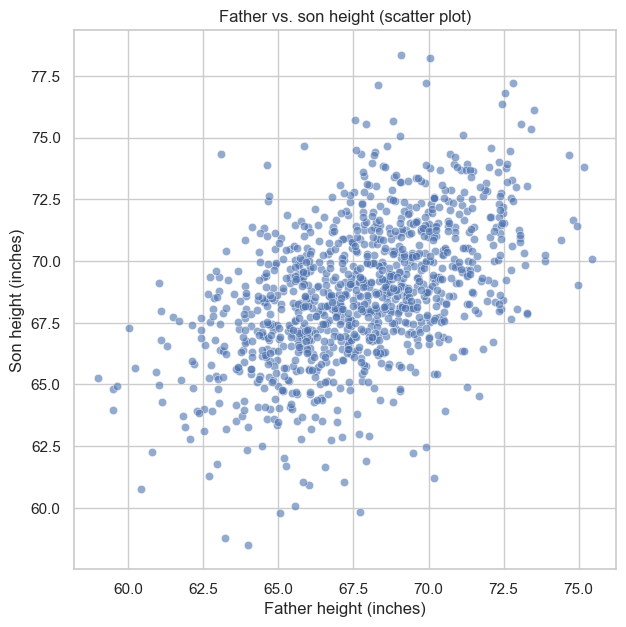

In [6]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=fsdata, x='father', y='son', alpha=0.6)
plt.title('Father vs. son height (scatter plot)')
plt.xlabel('Father height (inches)')
plt.ylabel('Son height (inches)')
plt.show()

## 4. Recap: $t$-tests
Two classical tests from your earlier statistics course, useful as a warm-up before regression.
1. A *paired* $t$-test to compare father and son means (the observations are naturally paired by family).
2. A one-sample $t$-test to check whether the average son height exceeds 67 inches.

Both are shown twice: first via manual formulas, then with `scipy` for confirmation.

### 4.1 Paired $t$-test (sons vs fathers)

In [7]:
diff = fsdata['son'] - fsdata['father']
mean_diff = diff.mean()
sd_diff = diff.std(ddof=1)
n = len(diff)

standard_error = sd_diff / np.sqrt(n)
t_statistic = mean_diff / standard_error
degrees_of_freedom = n - 1

p_value_two_sided = 2 * (1 - stats.t.cdf(abs(t_statistic), df=degrees_of_freedom))

print(f"Mean difference (son - father): {mean_diff:.3f} inches")
print(f"t statistic: {t_statistic:.3f}, df: {degrees_of_freedom}")
print(f"Two-sided p-value: {p_value_two_sided:.4f}")

Mean difference (son - father): 0.997 inches
t statistic: 11.789, df: 1077
Two-sided p-value: 0.0000


In [8]:
scipy_result = stats.ttest_rel(fsdata['son'], fsdata['father'])
print(scipy_result)

TtestResult(statistic=11.788549038237012, pvalue=2.957226369228171e-30, df=1077)


### 4.2 One-sample $t$-test (is the mean son height > 67 inches?)

In [9]:
mu_0 = 67
sons = fsdata['son']
mean_son = sons.mean()
std_son = sons.std(ddof=1)
n = len(sons)

standard_error = std_son / np.sqrt(n)
t_statistic = (mean_son - mu_0) / standard_error
p_value_one_sided = 1 - stats.t.cdf(t_statistic, df=n - 1)

print(f"Sample mean: {mean_son:.3f} inches")
print(f"t statistic: {t_statistic:.3f}, df: {n - 1}")
print(f"One-sided p-value (H1: mean > 67): {p_value_one_sided:.4f}")

Sample mean: 68.684 inches
t statistic: 19.644, df: 1077
One-sided p-value (H1: mean > 67): 0.0000


In [10]:
scipy_result = stats.ttest_1samp(sons, popmean=mu_0, alternative='greater')
print(scipy_result)

TtestResult(statistic=19.644323273595266, pvalue=5.6639323832923115e-74, df=1077)


## 5. Least squares estimates by hand
Lecture 1 estimates $\beta_0, \beta_1$ in model $(\ast)$ by minimising the sum of squared vertical deviations

$$S(\beta_0, \beta_1) = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2 .$$

The minimisers are the **least squares estimates** (LSE; also ordinary least squares, OLS; Czech: odhady metodou nejmenších čtverců). For normally distributed errors they coincide with the **maximum likelihood estimates** (MLE; maximálně věrohodné odhady). Lecture 1, formula (2.1):

$$\widehat{\beta}_1 = \frac{\sum_{i=1}^{n} x_i y_i - n\,\overline{x}\,\overline{y}}{\sum_{i=1}^{n} x_i^2 - n\,\overline{x}^2}, \qquad \widehat{\beta}_0 = \overline{y} - \widehat{\beta}_1 \overline{x}.$$

**Exercise (on the board).** Define the centred sums

$$S_{xx} = \sum_{i=1}^{n} (x_i - \overline{x})^2, \qquad S_{xy} = \sum_{i=1}^{n} (x_i - \overline{x})(y_i - \overline{y}).$$

Show that formula (2.1) can be written as

$$\widehat{\beta}_1 = \frac{S_{xy}}{S_{xx}}, \qquad \text{and that} \qquad S_{xy} = \sum_{i=1}^{n} (x_i - \overline{x})\, y_i .$$

(The lecture slides use the form (2.1) only; the last identity is the form used in the proofs in the lecture notes.) The next cell keeps the solution for later.

We then compute the estimates in several ways and show that they agree:
1. the lecture formula (2.1) and $S_{xy}/S_{xx}$ from the exercise,
2. the covariance/variance relationship $\widehat{\beta}_1 = \widehat{\mathrm{cov}}(x, y) / \widehat{\mathrm{var}}(x)$ (both sample moments divide by $n-1$, so this is again $S_{xy}/S_{xx}$),
3. the numerical least squares solution (`np.linalg.lstsq`; R: `coef(lm(son ~ father, data = fsdata))`).

In [11]:
# Solution of the board exercise. It is kept as a string so that nothing is shown yet.
# To display the derivation, remove the "# " from the last line and run the cell.
from IPython.display import Markdown, display

solution_board = r"""
**Solution.** Use $\sum_{i=1}^{n} x_i = n\overline{x}$, $\sum_{i=1}^{n} y_i = n\overline{y}$ and $\sum_{i=1}^{n} (x_i - \overline{x}) = 0$.

*Denominator.*
$$S_{xx} = \sum_{i=1}^{n} (x_i - \overline{x})^2 = \sum_{i=1}^{n} x_i^2 - 2\overline{x}\sum_{i=1}^{n} x_i + n\overline{x}^2
 = \sum_{i=1}^{n} x_i^2 - 2n\overline{x}^2 + n\overline{x}^2 = \sum_{i=1}^{n} x_i^2 - n\overline{x}^2 .$$

*Numerator.*
$$S_{xy} = \sum_{i=1}^{n} (x_i - \overline{x})(y_i - \overline{y})
 = \sum_{i=1}^{n} x_i y_i - \overline{y}\sum_{i=1}^{n} x_i - \overline{x}\sum_{i=1}^{n} y_i + n\overline{x}\,\overline{y}
 = \sum_{i=1}^{n} x_i y_i - n\overline{x}\,\overline{y} - n\overline{x}\,\overline{y} + n\overline{x}\,\overline{y}
 = \sum_{i=1}^{n} x_i y_i - n\overline{x}\,\overline{y} .$$

Dividing the two identities gives formula (2.1) in the form $\widehat{\beta}_1 = S_{xy}/S_{xx}$.

*Second identity.*
$$S_{xy} = \sum_{i=1}^{n} (x_i - \overline{x})\, y_i - \overline{y}\sum_{i=1}^{n} (x_i - \overline{x}) = \sum_{i=1}^{n} (x_i - \overline{x})\, y_i ,$$
because the last sum is zero. Hence
$$\widehat{\beta}_1 = \sum_{i=1}^{n} \frac{x_i - \overline{x}}{S_{xx}}\, y_i ,$$
a linear combination of the observations $y_i$ with fixed weights. This is the form used in Lecture 2 to derive $\mathrm{E}\,\widehat{\beta}_1 = \beta_1$ and $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / S_{xx}$.
"""

# display(Markdown(solution_board))

In [12]:
Y = fsdata['son'].to_numpy()      # response y_i
X = fsdata['father'].to_numpy()   # explanatory variable x_i
n = len(X)

x_mean = X.mean()
y_mean = Y.mean()

# lecture formula (2.1)
beta1_from_sums = (np.sum(X * Y) - n * x_mean * y_mean) / (np.sum(X ** 2) - n * x_mean ** 2)
beta0_from_sums = y_mean - beta1_from_sums * x_mean

# centred sums from the board exercise
S_xx = np.sum((X - x_mean) ** 2)
S_xy = np.sum((X - x_mean) * (Y - y_mean))
beta1_centred = S_xy / S_xx
beta1_centred_y = np.sum((X - x_mean) * Y) / S_xx

print(f"S_xx = {S_xx:.3f}, S_xy = {S_xy:.3f}")
print(f"beta1_hat, lecture formula (2.1)        : {beta1_from_sums:.6f}")
print(f"beta1_hat, S_xy / S_xx                  : {beta1_centred:.6f}")
print(f"beta1_hat, sum (x_i - x_bar) y_i / S_xx : {beta1_centred_y:.6f}")
print(f"beta0_hat                               : {beta0_from_sums:.6f}")

S_xx = 8114.444, S_xy = 4171.579
beta1_hat, lecture formula (2.1)        : 0.514093
beta1_hat, S_xy / S_xx                  : 0.514093
beta1_hat, sum (x_i - x_bar) y_i / S_xx : 0.514093
beta0_hat                               : 33.886604


In [13]:
# Covariance / variance formulation
cov_xy = np.cov(X, Y, ddof=1)[0, 1]
var_x = np.var(X, ddof=1)

beta1_from_cov = cov_xy / var_x
beta0_from_cov = y_mean - beta1_from_cov * x_mean

print(f"Beta1 (slope) from covariance: {beta1_from_cov:.4f}")
print(f"Beta0 (intercept) from covariance: {beta0_from_cov:.4f}")

Beta1 (slope) from covariance: 0.5141
Beta0 (intercept) from covariance: 33.8866


In [14]:
# Linear algebra / least squares solution
X_design = np.column_stack((np.ones_like(X), X))
beta_hat, *_ = np.linalg.lstsq(X_design, Y, rcond=None)

beta0_lstsq, beta1_lstsq = beta_hat
print(f"Beta0 from lstsq: {beta0_lstsq:.4f}")
print(f"Beta1 from lstsq: {beta1_lstsq:.4f}")

Beta0 from lstsq: 33.8866
Beta1 from lstsq: 0.5141


In [15]:
comparison = pd.DataFrame({
    'approach': ['lecture formula (2.1)', 'covariance / variance', 'numerical least squares'],
    'beta0': [beta0_from_sums, beta0_from_cov, beta0_lstsq],
    'beta1': [beta1_from_sums, beta1_from_cov, beta1_lstsq]
})
comparison

,approach,beta0,beta1
0,lecture formula (2.1),33.887,0.514
1,covariance / variance,33.887,0.514
2,numerical least squares,33.887,0.514


### Illustration: what least squares minimises
The red vertical segments are the deviations $y_i - \beta_0 - \beta_1 x_i$ of a few points from the line; $S(\beta_0, \beta_1)$ adds up their squares and the least squares line makes this sum as small as possible (geometric interpretation from Lecture 1). Note that the distances are measured vertically, in the direction of $y$: the method treats $x$ as exact and puts all the error into $y$. (The lecture notes mention total least squares, which uses perpendicular distances; we will not need it.)

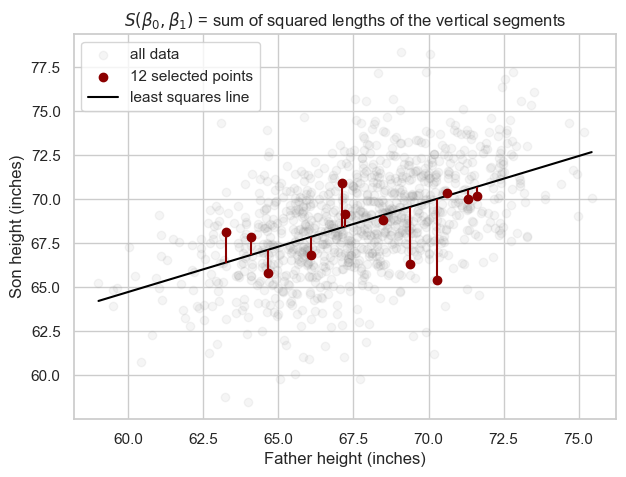

In [16]:
rng = np.random.default_rng(1)
idx = rng.choice(n, size=12, replace=False)   # a few points to keep the picture readable

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X, Y, alpha=0.08, color='grey', label='all data')
ax.scatter(X[idx], Y[idx], color='darkred', zorder=3, label='12 selected points')
x_line = np.linspace(X.min(), X.max(), 100)
ax.plot(x_line, beta0_from_sums + beta1_from_sums * x_line, color='black', label='least squares line')
for i in idx:
    ax.vlines(X[i], beta0_from_sums + beta1_from_sums * X[i], Y[i], color='darkred', linewidth=1.5)
ax.set_xlabel('Father height (inches)')
ax.set_ylabel('Son height (inches)')
ax.set_title(r'$S(\beta_0, \beta_1)$ = sum of squared lengths of the vertical segments')
ax.legend()
plt.show()

## 6. Fitted values, residuals and the estimate of $\sigma^2$
With the estimates in hand we obtain the **fitted values** (predictions of the model, estimates of $\mathrm{E}\,Y_i$; Czech: predikce modelu, vyrovnané hodnoty) and the **residuals** (rezidua)

$$\widehat{y}_i = \widehat{\beta}_0 + \widehat{\beta}_1 x_i, \qquad \widehat{e}_i = y_i - \widehat{y}_i, \qquad SSE = \sum_{i=1}^{n} \widehat{e}_i^{\,2}.$$

$SSE$ is the **sum of squares of errors** (also residual sum of squares, RSS; reziduální součet čtverců). Lecture 1 gives two estimates of the error variance $\sigma^2$:

- the maximum likelihood estimate $\widehat{\sigma}^2 = \dfrac{1}{n} SSE$, which is biased,
- the unbiased estimate $s_n^2 = \dfrac{1}{n-2} SSE$, which is the one used in practice.

The square root $s_n$ is the **standard error of the regression** (the lecture calls it the standard error; R prints it as `Residual standard error` in `summary(lm(...))`, `statsmodels` stores $s_n^2$ as `model.scale`; Czech: standardní chyba regrese). Note that $s_n$ itself is *not* an unbiased estimate of $\sigma$; in general $\mathrm{E}\, s_n \le \sigma$.

The residuals of a least squares fit with intercept always satisfy the **normal equations** (normální rovnice) $\sum_i \widehat{e}_i = 0$ and $\sum_i x_i \widehat{e}_i = 0$, which are just the conditions $\partial S/\partial\beta_0 = 0$ and $\partial S/\partial\beta_1 = 0$; we verify this numerically.

In [17]:
b0_hat, b1_hat = beta0_from_sums, beta1_from_sums

y_hat = b0_hat + b1_hat * X
e_hat = Y - y_hat
SSE = np.sum(e_hat ** 2)

sigma2_mle = SSE / n          # biased MLE
s_n2 = SSE / (n - 2)          # unbiased estimate of sigma^2
s_n = np.sqrt(s_n2)           # residual standard error

print(f"SSE                 : {SSE:.3f}")
print(f"sigma^2 (MLE, /n)   : {sigma2_mle:.4f}")
print(f"s_n^2 (/(n-2))      : {s_n2:.4f}")
print(f"s_n                 : {s_n:.4f}")
print()
print(f"sum of residuals        : {np.sum(e_hat):.2e}   (should be 0)")
print(f"sum of x_i * residuals  : {np.sum(X * e_hat):.2e}   (should be 0)")

SSE                 : 6388.001
sigma^2 (MLE, /n)   : 5.9258
s_n^2 (/(n-2))      : 5.9368
s_n                 : 2.4366

sum of residuals        : 1.88e-11   (should be 0)
sum of x_i * residuals  : -6.80e-10   (should be 0)


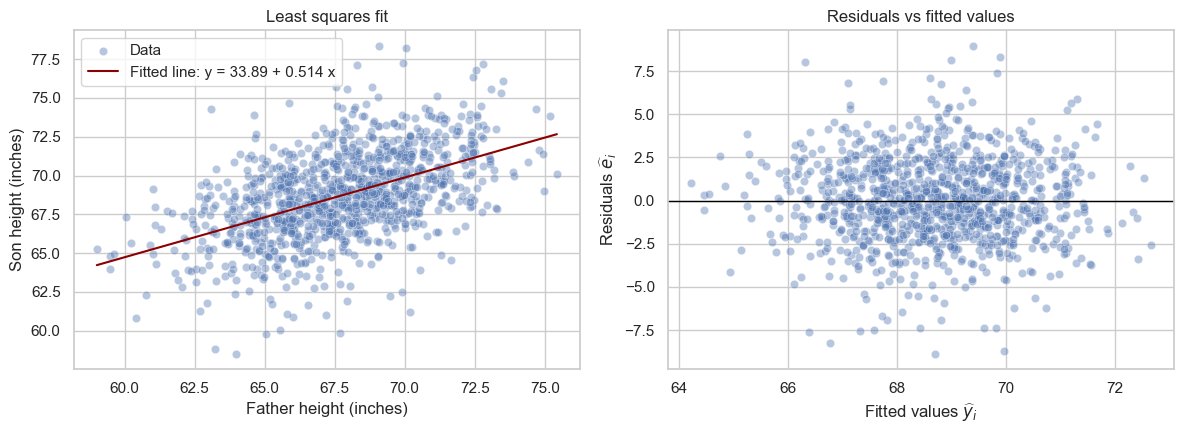

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(x=X, y=Y, alpha=0.4, ax=axes[0], label='Data')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, b0_hat + b1_hat * x_line, color='darkred',
             label=f'Fitted line: y = {b0_hat:.2f} + {b1_hat:.3f} x')
axes[0].set_xlabel('Father height (inches)')
axes[0].set_ylabel('Son height (inches)')
axes[0].set_title('Least squares fit')
axes[0].legend()

sns.scatterplot(x=y_hat, y=e_hat, alpha=0.4, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Fitted values $\\widehat{y}_i$')
axes[1].set_ylabel('Residuals $\\widehat{e}_i$')
axes[1].set_title('Residuals vs fitted values')

plt.tight_layout()
plt.show()

### Small simulation: $s_n^2$ is unbiased, $s_n$ is not
Lecture 1 remarks that $\mathrm{E}\, s_n^2 = \sigma^2$ for any error distribution, while $\mathrm{E}\, s_n \le \sigma$ (a general property of unbiased variance estimates). We check it by simulation: generate data from model $(\ast)$ with known $\sigma$, fit the line, store $s_n^2$, repeat many times and average. The maximum likelihood estimate $\widehat{\sigma}^2 = SSE/n$ is included for comparison.

In [19]:
rng = np.random.default_rng(2026)
sigma_true = 2.0
n_sim, reps = 10, 5000
x_sim = np.linspace(0, 1, n_sim)

y_sim = 1.0 + 2.0 * x_sim + rng.normal(0, sigma_true, size=(reps, n_sim))   # one row = one simulated sample
x_c = x_sim - x_sim.mean()
b1_sim = (y_sim @ x_c) / np.sum(x_c ** 2)                                    # slope for every sample at once
b0_sim = y_sim.mean(axis=1) - b1_sim * x_sim.mean()
resid_sim = y_sim - b0_sim[:, None] - b1_sim[:, None] * x_sim
sse_sim = np.sum(resid_sim ** 2, axis=1)

s_n2_sim = sse_sim / (n_sim - 2)
sigma2_mle_sim = sse_sim / n_sim

print(f"n = {n_sim}, {reps} simulated samples, true sigma^2 = {sigma_true**2:.3f}, true sigma = {sigma_true:.3f}")
print(f"mean of s_n^2          : {s_n2_sim.mean():.3f}   (unbiased)")
print(f"mean of MLE sigma_hat^2: {sigma2_mle_sim.mean():.3f}   (biased downwards by the factor (n-2)/n)")
print(f"mean of s_n            : {np.sqrt(s_n2_sim).mean():.3f}   (below sigma, as the lecture says)")

n = 10, 5000 simulated samples, true sigma^2 = 4.000, true sigma = 2.000
mean of s_n^2          : 3.990   (unbiased)
mean of MLE sigma_hat^2: 3.192   (biased downwards by the factor (n-2)/n)
mean of s_n            : 1.936   (below sigma, as the lecture says)


## 7. Preview of Lecture 2: standard errors of $\widehat{\beta}_0, \widehat{\beta}_1$
Lecture 2 shows that the least squares estimates are unbiased and that

$$\mathrm{Var}(\widehat{\beta}_1) = \frac{\sigma^2}{S_{xx}}, \qquad
  \mathrm{Var}(\widehat{\beta}_0) = \sigma^2 \left( \frac{1}{n} + \frac{\overline{x}^2}{S_{xx}} \right).$$

Replacing the unknown $\sigma^2$ by $s_n^2$ gives the estimated variances

$$\widehat{\sigma}^2(\widehat{\beta}_0) = s_n^2 \left( \frac{1}{n} + \frac{\overline{x}^2}{S_{xx}} \right) = s_n^2\, \delta_0, \qquad
  \widehat{\sigma}^2(\widehat{\beta}_1) = \frac{s_n^2}{S_{xx}} = s_n^2\, \delta_1,$$

where $\delta_0, \delta_1$ are called *variance multiplication factors* in the lecture notes. Their square roots are the **standard errors of the estimates** (estimated standard deviations of $\widehat{\beta}_0, \widehat{\beta}_1$; the `Std. Error` column in R and `statsmodels`; Czech: standardní chyby odhadů),

$$\widehat{\sigma}(\widehat{\beta}_0) = s_n \sqrt{\delta_0} = s_n \sqrt{\frac{1}{n} + \frac{\overline{x}^2}{S_{xx}}}, \qquad
  \widehat{\sigma}(\widehat{\beta}_1) = s_n \sqrt{\delta_1} = \frac{s_n}{\sqrt{S_{xx}}} .$$

For now just compute them; confidence intervals and tests built from these quantities come next week.

In [20]:
delta_0 = 1 / n + x_mean ** 2 / S_xx     # variance multiplication factor for beta0_hat
delta_1 = 1 / S_xx                        # variance multiplication factor for beta1_hat

var_b0_hat = s_n2 * delta_0
var_b1_hat = s_n2 * delta_1

se_b0 = np.sqrt(var_b0_hat)
se_b1 = np.sqrt(var_b1_hat)

pd.Series({
    's_n (standard error of the regression)': s_n,
    'delta_0': delta_0,
    'delta_1': delta_1,
    'estimated Var(beta0_hat)': var_b0_hat,
    'estimated Var(beta1_hat)': var_b1_hat,
    'SE(beta0_hat)': se_b0,
    'SE(beta1_hat)': se_b1,
}).map('{:.4g}'.format).to_frame('value')

,value
s_n (standard error of the regression),2.437
delta_0,0.5655
delta_1,0.0001232
estimated Var(beta0_hat),3.358
estimated Var(beta1_hat),0.0007316
SE(beta0_hat),1.832
SE(beta1_hat),0.02705


## 8. Preview of Lecture 4: regression through the origin
Sometimes a model **without intercept** (regression through the origin; Czech: regrese skrz počátek), $Y_i = \beta_1 x_i + e_i$, is considered. Lecture 4 treats it properly (estimates, tests and the ANOVA table for the case $\beta_0 = 0$); here we only need the estimate, because Homework 01 compares both models. Minimising $S(\beta_1) = \sum_i (y_i - \beta_1 x_i)^2$ gives a single normal equation and

$$\widehat{\beta}_1 = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}, \qquad
  s_n^2 = \frac{1}{n-1} \sum_{i=1}^{n} (y_i - \widehat{\beta}_1 x_i)^2,$$

with $n-1$ degrees of freedom because only one parameter is estimated. In matrix form both models solve the normal equations $\mathbf{X}^\top \mathbf{X}\, \widehat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{y}$, where the design matrix $\mathbf{X}$ has one column ($x_i$) or two columns ($1$ and $x_i$); this matrix view is the bridge to multiple regression later in the course.

In [21]:
IX = np.column_stack([np.ones(n), X])   # design matrix with intercept
X_no_const = X.reshape(-1, 1)            # design matrix without intercept

beta_hat_no_const = np.linalg.solve(X_no_const.T @ X_no_const, X_no_const.T @ Y)
beta_hat_with_const = np.linalg.solve(IX.T @ IX, IX.T @ Y)

# explicit formula for the model through the origin and its variance estimate (n - 1 degrees of freedom)
beta1_origin = np.sum(X * Y) / np.sum(X ** 2)
s_n2_origin = np.sum((Y - beta1_origin * X) ** 2) / (n - 1)

print(f"beta1_hat through the origin : {beta1_origin:.6f}   (normal equations: {beta_hat_no_const[0]:.6f})")
print(f"s_n^2 through the origin     : {s_n2_origin:.4f}   vs   s_n^2 with intercept: {s_n2:.4f}")

pd.DataFrame({
    'model': ['through the origin', 'with intercept'],
    'beta0': [0.0, beta_hat_with_const[0]],
    'beta1': [beta_hat_no_const[0], beta_hat_with_const[1]]
})

beta1_hat through the origin : 1.013908   (normal equations: 1.013908)
s_n^2 through the origin     : 7.8166   vs   s_n^2 with intercept: 5.9368


,model,beta0,beta1
0,through the origin,0.000,1.014
1,with intercept,33.887,0.514


## 9. The same fit with `statsmodels`
`statsmodels` will be our workhorse for inference. Its coefficient table has the same layout as R's `summary(lm(son ~ father, data = fsdata))` used in the lectures: estimates, standard errors, $t$ values and $p$-values. Unlike R, `statsmodels` does not print the standard error of the regression $s_n$ in the summary; it is available as `np.sqrt(model.scale)`. Check that the coefficients and the standard errors agree with our manual computation. For now ignore the remaining columns and rows of the summary (`t`, `P>|t|`, the confidence limits, `R-squared`, `F-statistic`): $t$-tests and confidence intervals come in Lecture 2, $R^2$ and the $F$-test in Lecture 3.

In [22]:
model_no_intercept = sm.OLS(Y, X_no_const).fit()
model_with_intercept = sm.OLS(Y, sm.add_constant(X)).fit()

pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat', 'SE(beta0_hat)', 'SE(beta1_hat)', 's_n'],
    'manual': [b0_hat, b1_hat, se_b0, se_b1, s_n],
    'statsmodels': [model_with_intercept.params[0], model_with_intercept.params[1],
                    model_with_intercept.bse[0], model_with_intercept.bse[1],
                    np.sqrt(model_with_intercept.scale)]
})

,quantity,manual,statsmodels
0,beta0_hat,33.887,33.887
1,beta1_hat,0.514,0.514
2,SE(beta0_hat),1.832,1.832
3,SE(beta1_hat),0.027,0.027
4,s_n,2.437,2.437


In [23]:
print(model_with_intercept.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.12e-69
Time:                        09:23:58   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

In [24]:
results_preview = pd.DataFrame({
    'model': ['no intercept', 'with intercept'],
    'beta0': [0.0, model_with_intercept.params[0]],
    'beta1': [model_no_intercept.params[0], model_with_intercept.params[1]],
    'R_squared': [model_no_intercept.rsquared, model_with_intercept.rsquared]
})
results_preview

,model,beta0,beta1,R_squared
0,no intercept,0.000,1.014,0.998
1,with intercept,33.887,0.514,0.251


### Comparing the two fitted lines
Notice how the line forced through the origin (blue) differs from the line with a fitted intercept (red), especially for shorter fathers. Whether the intercept is needed is a question we will answer with a test in Lecture 2. Do not compare the two models by the `R_squared` column yet: for a model without intercept it is defined differently (in `statsmodels` as well as in R), we return to $R^2$ with the ANOVA table in Lecture 3.

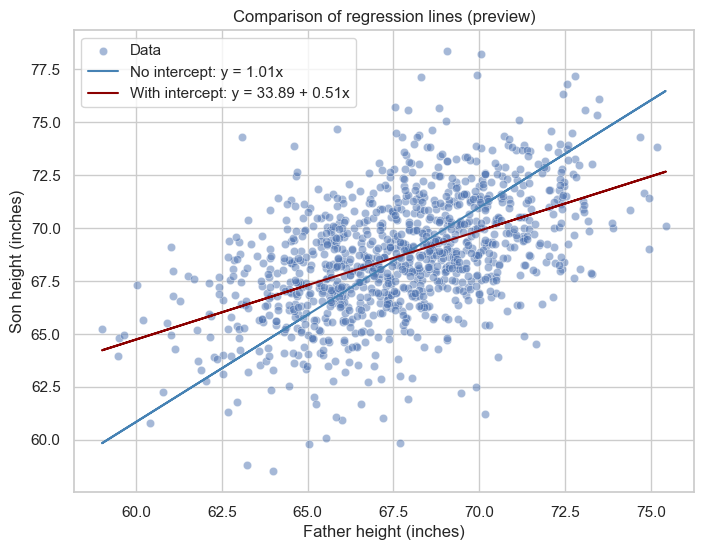

In [25]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X, y=Y, alpha=0.5, label='Data')
plt.plot(X, X * beta_hat_no_const[0], color='steelblue', label=f'No intercept: y = {beta_hat_no_const[0]:.2f}x')
plt.plot(X, model_with_intercept.params[0] + model_with_intercept.params[1] * X,
         color='darkred', label=f'With intercept: y = {model_with_intercept.params[0]:.2f} + {model_with_intercept.params[1]:.2f}x')
plt.xlabel('Father height (inches)')
plt.ylabel('Son height (inches)')
plt.title('Comparison of regression lines (preview)')
plt.legend()
plt.show()


### Optional challenge: what happens with outliers?
Try adding a couple of extreme points and re-running the fits above. How sensitive are the coefficients? A code scaffold is provided if you want to experiment.

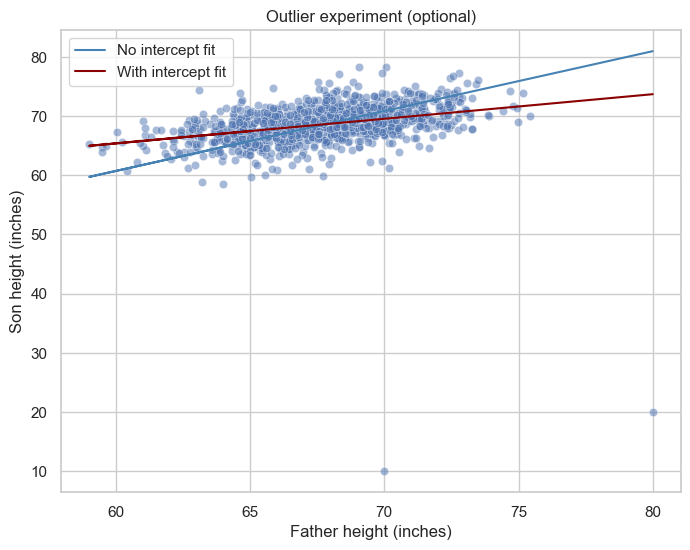

,model,beta0,beta1
0,no intercept (outliers),0.000,1.012
1,with intercept (outliers),40.445,0.416


In [26]:
fsdata_outliers = fsdata.copy()
outliers = pd.DataFrame({'father': [70, 80], 'son': [10, 20]})
fsdata_outliers = pd.concat([fsdata_outliers, outliers], ignore_index=True)

model_no_intercept_out = smf.ols('son ~ -1 + father', data=fsdata_outliers).fit()
model_with_intercept_out = smf.ols('son ~ father', data=fsdata_outliers).fit()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=fsdata_outliers, x='father', y='son', alpha=0.5)
plt.plot(fsdata_outliers['father'], model_no_intercept_out.fittedvalues, color='steelblue', label='No intercept fit')
plt.plot(fsdata_outliers['father'], model_with_intercept_out.fittedvalues, color='darkred', label='With intercept fit')
plt.xlabel('Father height (inches)')
plt.ylabel('Son height (inches)')
plt.title('Outlier experiment (optional)')
plt.legend()
plt.show()

pd.DataFrame({
    'model': ['no intercept (outliers)', 'with intercept (outliers)'],
    'beta0': [0.0, model_with_intercept_out.params['Intercept']],
    'beta1': [model_no_intercept_out.params['father'], model_with_intercept_out.params['father']]
})

### Optional challenge 2: least squares vs least absolute deviations
Lecture 1 justifies least squares by the normal distribution of the errors. The lecture notes show what happens with a different error distribution: for Laplace (double exponential) errors the maximum likelihood estimate minimises the sum of **absolute** deviations $A(\beta_0, \beta_1) = \sum_i |y_i - \beta_0 - \beta_1 x_i|$ instead of the sum of squares. Such estimates are called least absolute deviations (LAD; the lecture notes say MAD, minimum absolute deviation; Czech: odhad metodou nejmenších absolutních odchylek) and are generally different from LSE.

The notes use three points $(0,0)$, $(1,0)$, $(\tfrac12, \tfrac12)$: least squares gives $\widehat{\beta}_0 = \tfrac16$, $\widehat{\beta}_1 = 0$, while the absolute-deviation fit gives $\widehat{\beta}_0 = \widehat{\beta}_1 = 0$ with $A = \tfrac12$. Verify this numerically (a general-purpose minimiser is enough for three points) and draw both lines. We come back to this idea in the exercise on robust regression.

LSE : beta0 = 0.1667, beta1 = 0.0000, S = 0.1667    (lecture notes: 1/6, 0)
LAD : beta0 = 0.0000, beta1 = 0.0000, A = 0.5000    (lecture notes: 0, 0, A = 1/2)


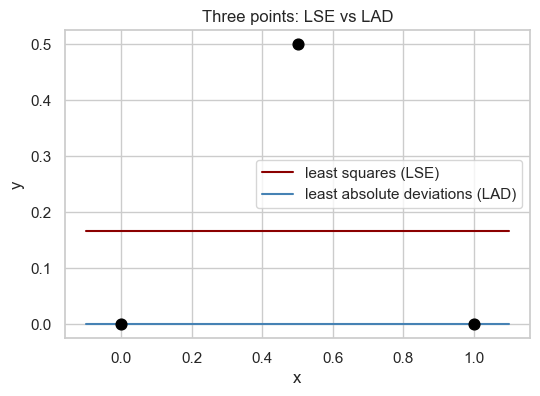

In [27]:
from scipy.optimize import minimize

pts_x = np.array([0.0, 1.0, 0.5])
pts_y = np.array([0.0, 0.0, 0.5])

def S_ls(b):    # sum of squared deviations
    return np.sum((pts_y - b[0] - b[1] * pts_x) ** 2)

def A_lad(b):   # sum of absolute deviations
    return np.sum(np.abs(pts_y - b[0] - b[1] * pts_x))

ls = minimize(S_ls, x0=[0.0, 0.0], method='Nelder-Mead', options={'xatol': 1e-10, 'fatol': 1e-12})
lad = minimize(A_lad, x0=[0.1, 0.1], method='Nelder-Mead', options={'xatol': 1e-10, 'fatol': 1e-12})

ls_b = np.round(ls.x, 6) + 0.0     # + 0.0 turns a numerical -0.0 into 0.0
lad_b = np.round(lad.x, 6) + 0.0

print(f"LSE : beta0 = {ls_b[0]:.4f}, beta1 = {ls_b[1]:.4f}, S = {ls.fun:.4f}    (lecture notes: 1/6, 0)")
print(f"LAD : beta0 = {lad_b[0]:.4f}, beta1 = {lad_b[1]:.4f}, A = {lad.fun:.4f}    (lecture notes: 0, 0, A = 1/2)")

xx = np.linspace(-0.1, 1.1, 50)
plt.figure(figsize=(6, 4))
plt.scatter(pts_x, pts_y, color='black', zorder=3, s=60)
plt.plot(xx, ls.x[0] + ls.x[1] * xx, color='darkred', label='least squares (LSE)')
plt.plot(xx, lad.x[0] + lad.x[1] * xx, color='steelblue', label='least absolute deviations (LAD)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Three points: LSE vs LAD')
plt.legend()
plt.show()

## 10. Check against the lecture example: speed of sound vs temperature
Lecture 2 works through a five-point example by hand: the speed of sound (m/s) measured at five temperatures (°C). The slides report

$\overline{x} = 30$, $\overline{y} = 348$, $\sum x_i y_i = 57\,140$, $\sum x_i^2 = 13\,300$, $S_{xx} = 8800$,
$\widehat{\beta}_1 = 0.561$, $\widehat{\beta}_0 = 331.16$, $s_n^2 = 18.95$, $s_n = 4.35$,
$\widehat{\sigma}(\widehat{\beta}_0) = 2.394$, $\widehat{\sigma}(\widehat{\beta}_1) = 0.046$,

followed by R's `summary(lm(rychlost ~ teplota))` and `confint(mod)`. Reproduce the numbers in Python. This is a good habit: whenever a lecture contains a worked example, recompute it. The 95 % confidence intervals printed at the end are a preview: we only check that Python reproduces the slide, the formula $\widehat{\beta}_j \pm t_{1-\alpha/2}(n-2)\, \widehat{\sigma}(\widehat{\beta}_j)$ behind them is derived in Lecture 2.

In [28]:
sound = pd.DataFrame({
    'temperature': [-20, 0, 20, 50, 100],
    'speed': [323, 327, 340, 364, 386]
})

x = sound['temperature'].to_numpy(dtype=float)
y = sound['speed'].to_numpy(dtype=float)
m = len(x)

xbar, ybar = x.mean(), y.mean()
Sxx = np.sum((x - xbar) ** 2)
b1 = (np.sum(x * y) - m * xbar * ybar) / (np.sum(x ** 2) - m * xbar ** 2)
b0 = ybar - b1 * xbar
sse = np.sum((y - b0 - b1 * x) ** 2)
sn2 = sse / (m - 2)
sn = np.sqrt(sn2)

print(f"x_bar = {xbar:.0f}, y_bar = {ybar:.0f}, sum(x*y) = {np.sum(x*y):.0f}, sum(x^2) = {np.sum(x**2):.0f}, S_xx = {Sxx:.0f}")
print(f"beta1_hat = {b1:.3f}, beta0_hat = {b0:.2f}")
print(f"s_n^2 = {sn2:.2f}, s_n = {sn:.2f}")
print(f"SE(beta0_hat) = {sn * np.sqrt(1/m + xbar**2 / Sxx):.3f}, SE(beta1_hat) = {sn / np.sqrt(Sxx):.3f}")

x_bar = 30, y_bar = 348, sum(x*y) = 57140, sum(x^2) = 13300, S_xx = 8800
beta1_hat = 0.561, beta0_hat = 331.16
s_n^2 = 18.95, s_n = 4.35
SE(beta0_hat) = 2.394, SE(beta1_hat) = 0.046


In [29]:
import warnings

sound_model = smf.ols('speed ~ temperature', data=sound).fit()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # the normality test in the summary needs at least 8 observations
    print(sound_model.summary())
print()
print('95% confidence intervals (compare with confint(mod) on the slide):')
print(sound_model.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                  speed   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     146.3
Date:                Mon, 21 Sep 2026   Prob (F-statistic):            0.00122
Time:                        09:23:59   Log-Likelihood:                -13.173
No. Observations:                   5   AIC:                             30.35
Df Residuals:                       3   BIC:                             29.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     331.1591      2.394    138.350      

## 11. What to remember
- Model $(\ast)$: $Y_i = \beta_0 + \beta_1 x_i + e_i$ with independent errors, $\mathrm{E}\, e_i = 0$, $\mathrm{Var}(e_i) = \sigma^2$. The $x_i$ are treated as fixed, the randomness sits in $e_i$.
- The least squares estimates $\widehat{\beta}_1 = \dfrac{\sum x_i y_i - n\overline{x}\,\overline{y}}{\sum x_i^2 - n\overline{x}^2} = \dfrac{S_{xy}}{S_{xx}} = \dfrac{\sum (x_i - \overline{x}) y_i}{S_{xx}}$, $\widehat{\beta}_0 = \overline{y} - \widehat{\beta}_1 \overline{x}$ can be obtained from raw or centred sums, from covariance/variance, or numerically. For normal errors they are also the maximum likelihood estimates.
- Residuals $\widehat{e}_i = y_i - \widehat{y}_i$ sum to zero and are orthogonal to $x$ (normal equations). The unbiased estimate of $\sigma^2$ is $s_n^2 = SSE/(n-2)$, not the MLE $SSE/n$; $s_n$ is the standard error of the regression (`Residual standard error` in R).
- Least squares is justified twice: for normal errors LSE = MLE, and for any error distribution with $\mathrm{E}\,e_i = 0$ and constant variance the LSE are BLUE, best linear unbiased estimators (Gauss–Markov theorem, Lecture 2).
- Standard errors $s_n/\sqrt{S_{xx}}$ and $s_n\sqrt{1/n + \overline{x}^2/S_{xx}}$ measure the precision of the estimates; Lecture 2 turns them into confidence intervals and tests.
- Forcing the line through the origin changes the slope appreciably; whether the intercept belongs in the model is a statistical question (test of $\beta_0 = 0$ in Lecture 2, the model through the origin in Lecture 4), not a matter of taste.

## Homework 01
The homework for this exercise (braking distance of cars) is in the separate notebook `01RAD_Ex01_HW.ipynb`. Work through it before the next exercise; a selected student solution and a reference solution will be published a week later.